<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Classification and KNN with NHL data

_Authors: Joseph Nelson (DC)_

---

Below you will practice KNN classification on a dataset of NHL statistics.

You will be predicting the `Rank` of a team from predictor variables of your choice.

In [85]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [86]:
# web location:
local_csv = '../data/NHL_Data_GA.csv'

### 1. Load the NHL data

In [87]:
# A:
local_csv=pd.read_csv("./data/NHL_Data_GA.csv")
local_csv.head()

,Team,PTS,Rank,TOI,GF,GA,GF60,GA60,GF%,SF,...,FF%,CF,CA,CF60,CA60,CF%,Sh%,Sv%,PDO,PIM
0,Washington10,121,1,2001:52:00,115,73,3.45,2.19,61.2,1112,...,51.3,2138,1935,64.1,58.0,52.5,10.34,93.03,1034,1269
1,Vancouver11,117,1,2056:14:00,94,72,2.74,2.10,56.6,1143,...,53.1,2144,1870,62.6,54.6,53.4,8.22,93.16,1014,985
2,San Jose10,113,1,1929:54:00,90,68,2.80,2.11,57.0,1065,...,50.9,1985,1876,61.7,58.3,51.4,8.45,93.46,1019,1195
3,Chicago10,112,1,2020:23:00,104,83,3.09,2.46,55.6,1186,...,58.1,2093,1572,62.2,46.7,57.1,8.77,90.44,992,966
4,Vancouver12,111,1,2052:02:00,86,74,2.51,2.16,53.8,1078,...,51.0,2085,1880,61.0,55.0,52.6,7.98,93.36,1013,1049


### 2. Perform any required data cleaning. Do some EDA.

In [88]:
# A:
local_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Team    90 non-null     object 
 1   PTS     90 non-null     int64  
 2   Rank    90 non-null     int64  
 3   TOI     90 non-null     object 
 4   GF      90 non-null     int64  
 5   GA      90 non-null     int64  
 6   GF60    90 non-null     float64
 7   GA60    90 non-null     float64
 8   GF%     90 non-null     float64
 9   SF      90 non-null     int64  
 10  SA      90 non-null     int64  
 11  SF60    90 non-null     float64
 12  SA60    90 non-null     float64
 13  SF%     90 non-null     float64
 14  FF      90 non-null     int64  
 15  FA      90 non-null     int64  
 16  FF60    90 non-null     float64
 17  FA60    90 non-null     float64
 18  FF%     90 non-null     float64
 19  CF      90 non-null     int64  
 20  CA      90 non-null     int64  
 21  CF60    90 non-null     float64
 22  CA60

In [89]:
local_csv.isnull().sum()

Team    0
PTS     0
Rank    0
TOI     0
GF      0
GA      0
GF60    0
GA60    0
GF%     0
SF      0
SA      0
SF60    0
SA60    0
SF%     0
FF      0
FA      0
FF60    0
FA60    0
FF%     0
CF      0
CA      0
CF60    0
CA60    0
CF%     0
Sh%     0
Sv%     0
PDO     0
PIM     0
dtype: int64

### 3. Set up the `Rank` variable as your target. How many classes are there?

In [90]:
# A:
y = local_csv['Rank']
X =local_csv.drop(columns=['Rank'])

In [91]:
#B:
local_csv['Rank'].nunique()

3

In [92]:
#c:
local_csv['Rank'].value_counts()

Rank
3    31
2    30
1    29
Name: count, dtype: int64

In [93]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20, stratify=y, random_state=99)

In [94]:
y_train.value_counts() , y_test.value_counts()

(Rank
 3    25
 2    24
 1    23
 Name: count, dtype: int64,
 Rank
 1    6
 2    6
 3    6
 Name: count, dtype: int64)

### 4. What is the baseline accuracy?

In [95]:
# A:# erorr
baseline_accuracy = local_csv['Rank'].value_counts(normalize=True).max()

print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Accuracy: 34.44%


### 5. Choose 4 features to be your predictor variables and set up your design matrix.

In [96]:
# A:
feature_cols = ['PTS', 'GF', 'GA', 'PIM']

# Set up your design matrix X
X = local_csv[feature_cols]

# Check the first few rows
X.head()

,PTS,GF,GA,PIM
0,121,115,73,1269
1,117,94,72,985
2,113,90,68,1195
3,112,104,83,966
4,111,86,74,1049


In [97]:
#cols=['PTS', 'CF60', 'PDO', 'SF','Rank']
#sns.pairplot(local_csv[cols],hue='Rank')

### 6. Fit a `KNeighborsClassifier` with 1 neighbor using the target and predictors.

In [98]:
# A:
knn=KNeighborsClassifier(n_neighbors=1)


In [99]:
knn.fit(X, y)

KNeighborsClassifier(n_neighbors=1)

### 7. Evaluate the accuracy of your model.
- Is it better than baseline?
- Is it legitimate?

In [100]:
# A:
accuracy = knn.score(X, y)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


### 8. Create a 50-50 train-test-split of your target and predictors. Refit the KNN and assess the accuracy.

In [101]:
# A:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Refit the KNN model on training data
knn.fit(X_train, y_train)

# Assess the accuracy on test data
accuracy = knn.score(X_test, y_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.5333333333333333


### 9. Evaluate the test accuracy of a KNN where K == number of rows in the training data.

In [102]:
# A:
k_value = X_train.shape[0]

# Instantiate KNN with K equal to training size
knn_all = KNeighborsClassifier(n_neighbors=k_value)

# Fit on training data
knn_all.fit(X_train, y_train)

# Evaluate accuracy on test data
test_accuracy = knn_all.score(X_test, y_test)
print("Test Accuracy with K = len(X_train):", test_accuracy)

Test Accuracy with K = len(X_train): 0.3111111111111111


### 10. Fit the KNN at values of K from 1 to the number of rows in the training data.
- Store the test accuracy in a list.
- Plot the test accuracy vs. the number of neighbors.

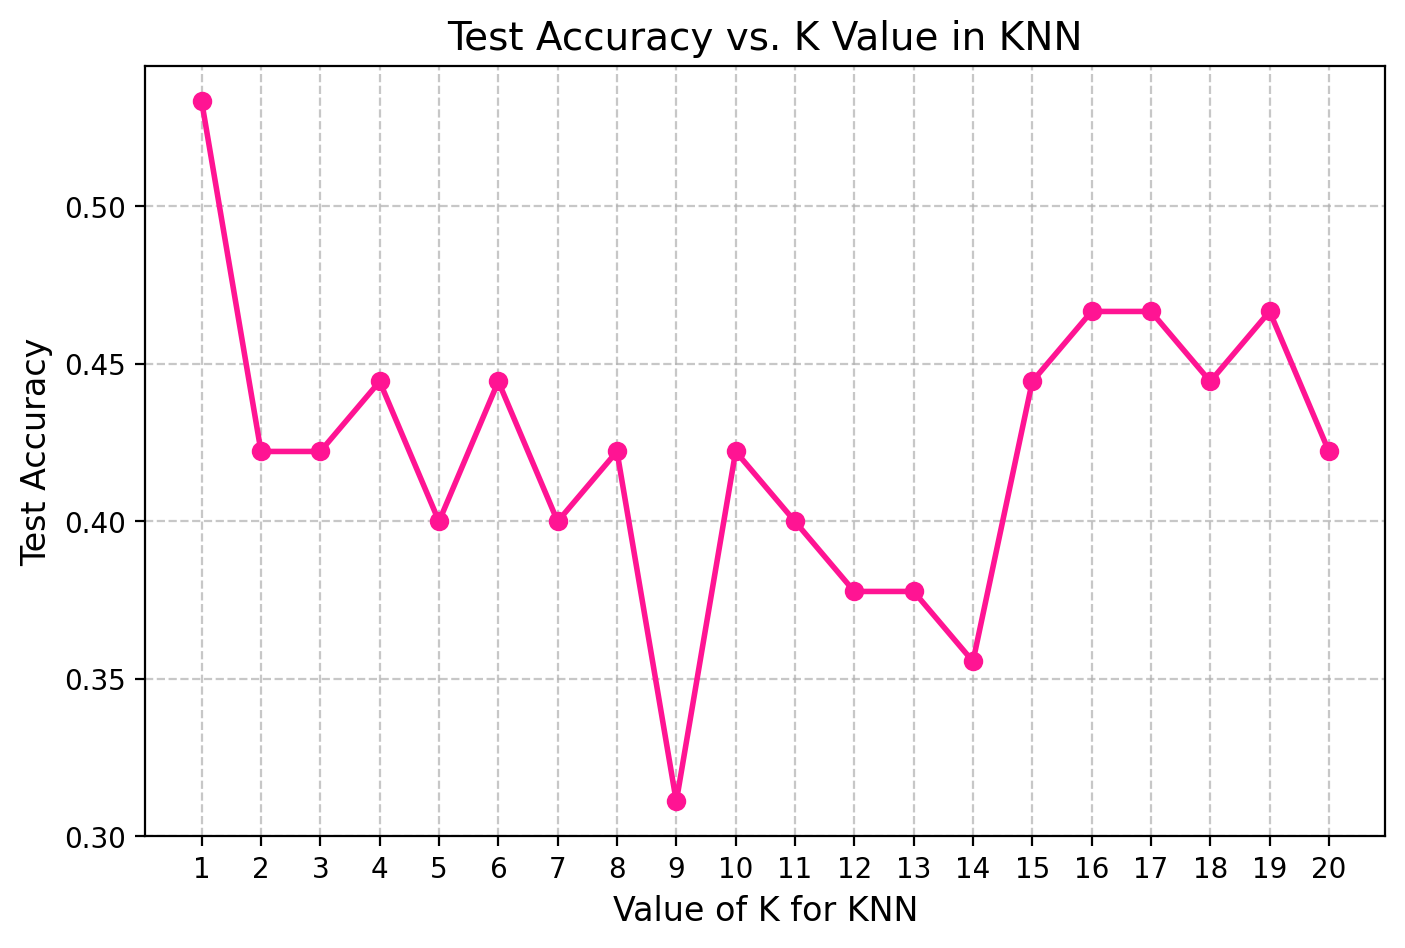

In [112]:
# A:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

test_accuracies = []
k_range = range(1, 21)

# 1. حساب الدقة لكل قيمة من K
for k in k_range:
    knn_loop = KNeighborsClassifier(n_neighbors=k)
    knn_loop.fit(X_train, y_train)
    acc = knn_loop.score(X_test, y_test)
    test_accuracies.append(acc)

# 2. رسم الـ Line Chart
plt.figure(figsize=(8, 5))

# استخدام plt.plot لعرض العلاقة الخطية
plt.plot(k_range, test_accuracies, color='deeppink', marker='o', linestyle='-', linewidth=2)

# إضافة العناوين والمحاور
plt.xlabel('Value of K for KNN', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Test Accuracy vs. K Value in KNN', fontsize=14)

plt.xticks(k_range)  # لعرض قيم K من 1 إلى 20 بوضوح
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

### 11. Fit KNN across different values of K and plot the mean cross-validated accuracy with 5 folds.

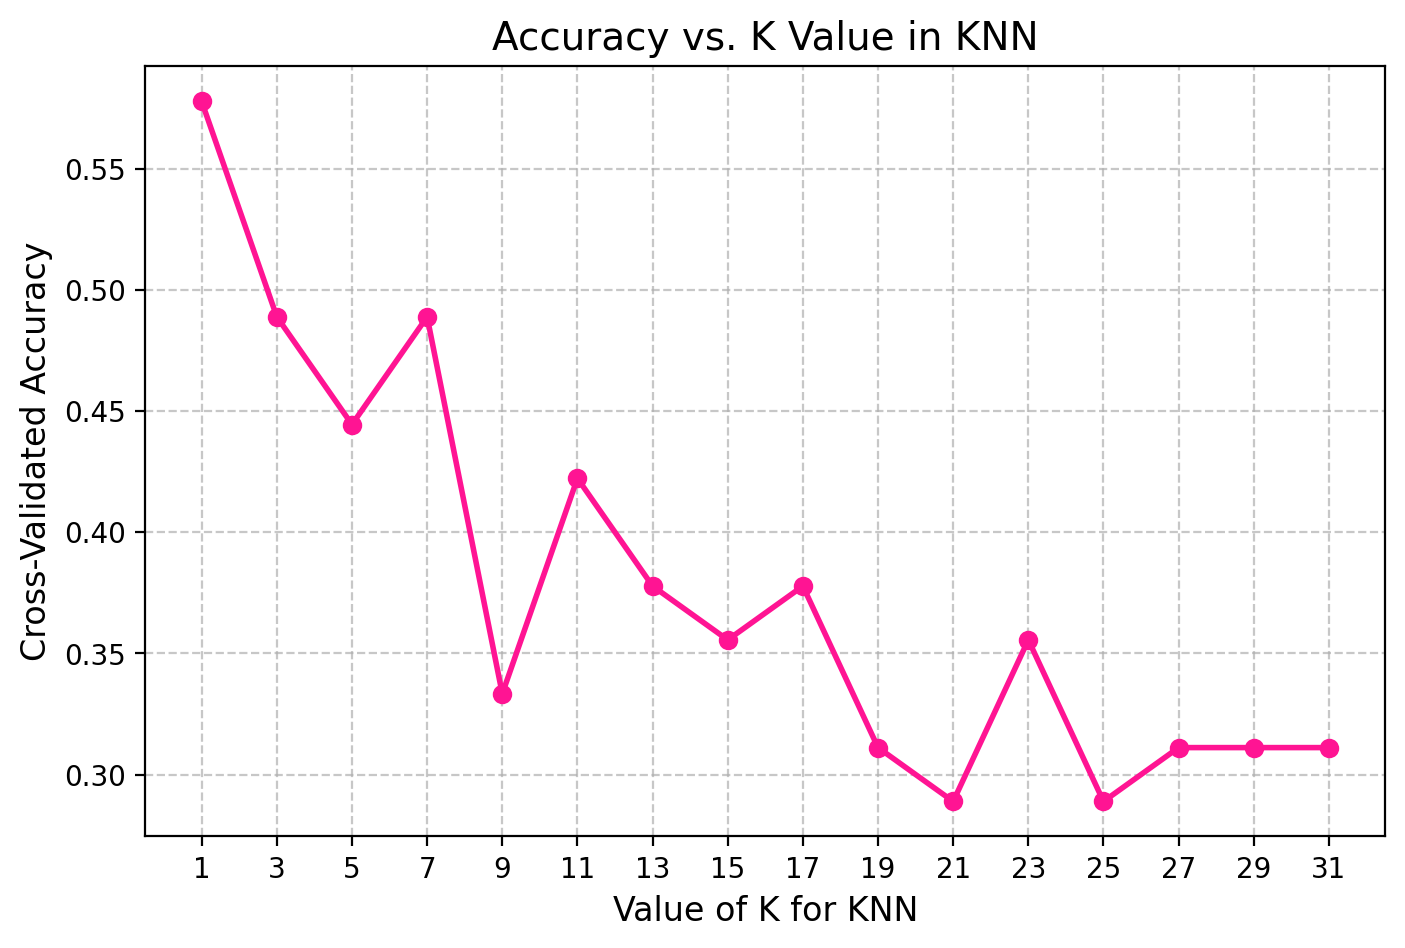

In [111]:
# A:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

cv_scores = []
k_range = range(1, 32, 2)

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# --- رسم الـ Line Chart ---
plt.figure(figsize=(8, 5))

# استخدام plt.plot بدلاً من plt.hist
plt.plot(k_range, cv_scores, color='deeppink', marker='o', linestyle='-', linewidth=2)

plt.xlabel('Value of K for KNN', fontsize=12)
plt.ylabel('Cross-Validated Accuracy', fontsize=12)
plt.title('Accuracy vs. K Value in KNN', fontsize=14)
plt.xticks(k_range)  # لعرض قيم K الفردية بوضوح على المحور
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

### 12. Standardize the predictor matrix and cross-validate across the different K.
- Plot the standardized mean cross-validated accuracy against the unstandardized. Which is better?
- Why?

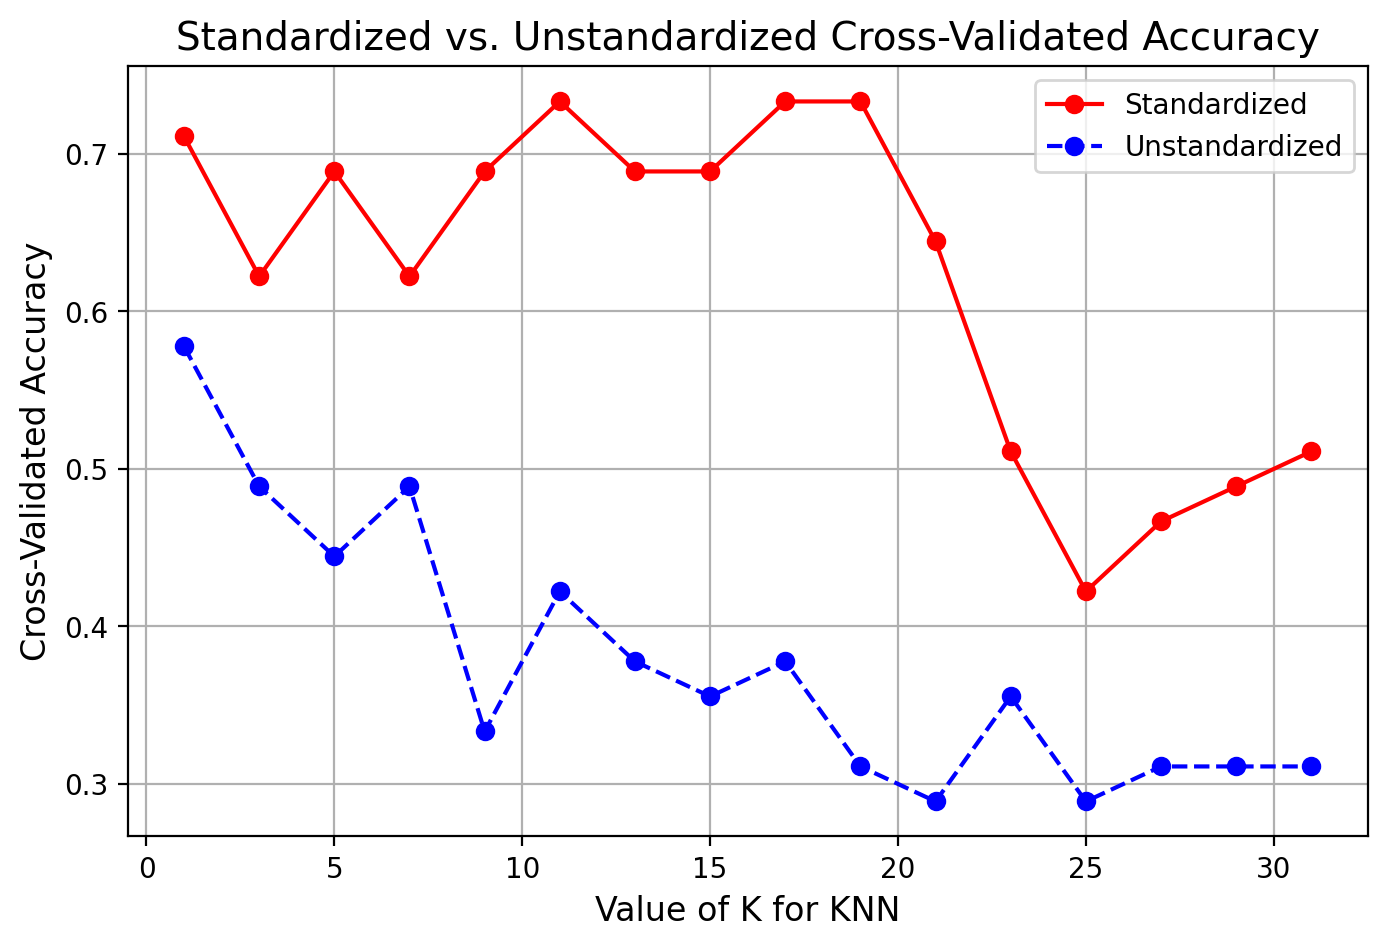

In [108]:
# A:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Perform cross-validation with scaled data
cv_scores_scaled = []
k_range = range(1, 32, 2)

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores_scaled.append(scores.mean())

# 3. Plot both standardized and unstandardized results to compare
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores_scaled, marker='o', color='r', label='Standardized')
plt.plot(k_range, cv_scores, marker='o', color='b', linestyle='--', label='Unstandardized')

plt.xlabel('Value of K for KNN', fontsize=12)
plt.ylabel('Cross-Validated Accuracy', fontsize=12)
plt.title('Standardized vs. Unstandardized Cross-Validated Accuracy', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

## What was the best 'k'?

Using `GridSearch` & `Pipeline` find the best `k` for the KNN model

In [110]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {'knn__n_neighbors': range(1, 32, 2)}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best k:", grid_search.best_params_['knn__n_neighbors'])
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best k: 1
Best Cross-Validation Accuracy: 0.711111111111111
